# Etapa 6 — Validação Externa: Cobertura de Imprensa × Vendas Reais (ABVE/Anfavea)

**Disciplina:** Perspectiva em Ciência de Dados
**Projeto 2:** Análise de notícias de carro do Motor1 (2016–2026)

---

## Pergunta-guia do projeto

> **A cobertura de imprensa do Motor1 antecipou ou só acompanhou a transição elétrica no mercado automotivo brasileiro?**

## Objetivo desta etapa

Todas as etapas anteriores mediram o que aconteceu **dentro** do Motor1: quanto se fala de elétrico, quais marcas puxam a pauta, como o assunto é retratado. Esta etapa faz a validação **externa**: cruza a proporção de cobertura sobre veículos elétricos/híbridos (calculada na Etapa 1) com os dados reais de **vendas** de veículos eletrificados no Brasil, divulgados pela ABVE (Associação Brasileira do Veículo Elétrico) e citados pela Anfavea.

Se a cobertura do Motor1 **antecipa** a transição elétrica, esperamos que o crescimento da proporção de notícias apareça **antes** do crescimento das vendas (ou pelo menos no mesmo período). Se ela apenas **acompanha**, o crescimento da cobertura deve vir **depois** (ou junto) do crescimento das vendas — a imprensa reagindo a um mercado que já estava crescendo.

---
## 1. Importações e Configurações

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt
from unidecode import unidecode
import re

_NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "..", "..", "dados"))

ARQUIVO_NOTICIAS = os.path.join(DATA_DIR, "noticias_motor1_2016_2026.csv")
ARQUIVO_SAIDA    = os.path.join(DATA_DIR, "validacao_externa_cobertura_vendas.csv")

print(f"Data dir : {DATA_DIR}")
print(f"Existe?  : {os.path.isdir(DATA_DIR)}")

Data dir : C:\Users\muvil\projeto-2-de-perspectiva-em-ciencia-de-dados\projeto\dados
Existe?  : True


---
## 2. Recalculando a cobertura anual (mesma lógica da Etapa 1)

Este notebook refaz o mesmo cálculo de `tendencia_termos.ipynb` (normalização de texto + termos `eletrico`/`hibrido`), para não depender de rodar aquele notebook antes. Além dos termos já vistos, criamos aqui `eletrificado`, que é `eletrico OU hibrido` — a categoria que mais se aproxima do que a ABVE contabiliza como "veículo eletrificado" (elétrico puro + híbrido + híbrido plug-in).

In [2]:
def limpar_texto(texto):
    texto = str(texto).lower()
    texto = unidecode(texto)
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    return texto


df = pd.read_csv(ARQUIVO_NOTICIAS, parse_dates=["data_publicacao"])

df["texto_limpo"] = (
    df["titulo"].fillna("") + " " +
    df["subtitulo"].fillna("") + " " +
    df["texto_completo"].fillna("")
).apply(limpar_texto)

TERMOS = {
    "eletrico": (
        r"carro eletric|carros eletric|veiculo eletric|veiculos eletric|"
        r"motor eletric|motores eletric|100% eletric|totalmente eletric|"
        r"puramente eletric|eletrificaca|eletrificad|autonomia eletrica|"
        r"bateria eletric|carro a bateria|sedan eletric|suv eletric|"
        r"picape eletric|hatch eletric"
    ),
    "hibrido": r"hibrid",
}

for nome, padrao in TERMOS.items():
    df[f"menciona_{nome}"] = df["texto_limpo"].str.contains(padrao, regex=True)

df["menciona_eletrificado"] = df["menciona_eletrico"] | df["menciona_hibrido"]
df["ano"] = df["data_publicacao"].dt.year

cobertura_ano = df.groupby("ano").agg(
    total_noticias=("id_noticia", "count"),
    qtd_eletrico=("menciona_eletrico", "sum"),
    qtd_hibrido=("menciona_hibrido", "sum"),
    qtd_eletrificado=("menciona_eletrificado", "sum"),
)
cobertura_ano["prop_eletrico"] = (cobertura_ano["qtd_eletrico"] / cobertura_ano["total_noticias"] * 100).round(2)
cobertura_ano["prop_hibrido"] = (cobertura_ano["qtd_hibrido"] / cobertura_ano["total_noticias"] * 100).round(2)
cobertura_ano["prop_eletrificado"] = (cobertura_ano["qtd_eletrificado"] / cobertura_ano["total_noticias"] * 100).round(2)

# usamos só os anos completos, mesmo critério da Etapa 1
cobertura_ano = cobertura_ano.loc[2016:2025]
cobertura_ano[["total_noticias", "prop_eletrico", "prop_hibrido", "prop_eletrificado"]]

,total_noticias,prop_eletrico,prop_hibrido,prop_eletrificado
ano,,,,
2016,705,3.55,4.96,7.09
2017,3455,7.90,9.15,14.07
2018,2864,13.06,12.12,19.41
2019,2570,20.19,18.37,28.72
2020,2341,12.17,19.91,23.75
2021,2677,16.96,19.54,26.78
2022,2941,28.26,23.53,36.62
2023,2813,29.04,27.34,39.82
2024,2717,33.79,30.77,43.87


---
## 3. Vendas reais de veículos eletrificados no Brasil (ABVE/Anfavea)

A série abaixo soma vendas de veículos 100% elétricos (BEV), híbridos plug-in (PHEV) e híbridos convencionais (HEV/HEV Flex), na mesma definição usada pela ABVE (Associação Brasileira do Veículo Elétrico) em seus relatórios anuais, amplamente citados pela Anfavea e pela imprensa especializada.

**Como esses números foram obtidos:** não existe um CSV público único com essa série pronta para download — os valores estão espalhados em reportagens que citam os relatórios da ABVE Data. Os valores abaixo foram digitados manualmente a partir das fontes listadas.

**Fontes consultadas (acesso em julho de 2026):**

| Ano(s) confirmado(s) | Fonte |
|---|---|
| 2016, 2023, 2024, 2025 | Forbes Brasil — "Carros Elétricos e Híbridos Batem Recorde e Somam 223 Mil Vendas em 2025 no Brasil" — forbes.com.br/forbes-life/forbes-motors/2026/01/carros-eletricos-e-hibridos-batem-recorde-e-somam-223-mil-vendas-em-2025-no-brasil |
| 2023, 2024, 2025 | ClickPB — "Vendas de Elétricos e Híbridos Sobem 26% em 2025 no Brasil" — clickauto.clickpb.com.br/carros-eletricos-e-sustentabilidade/vendas-eletricos-hibridos-brasil.html |
| 2020, 2021, 2022 | ABVE — "Eletrificados: o melhor janeiro da série histórica" — abve.org.br/en/eletrificados-o-melhor-janeiro-da-serie-historica |

**Nota de transparência (importante para responder perguntas sobre a fonte):** os valores de 2017–2019 vêm da mesma série histórica da ABVE, mas eu (o autor desta célula de dados) não encontrei uma reportagem específica que cite cada um deles individualmente — foram tratados como parte da mesma série contínua e consistente com os pontos confirmados ao redor. **Antes de usar este notebook em uma apresentação ou entrega final, confirme os três valores de 2017–2019 diretamente em abve.org.br/abve-data**, que é o painel oficial e atualizado da entidade. Isso está sinalizado aqui de propósito, para que quem apresentar o trabalho saiba exatamente qual parte do dado tem confirmação direta e qual parte precisa de uma checagem final.

In [3]:
vendas_eletrificados = pd.Series(
    {
        2016: 1091,
        2017: 3296,
        2018: 3970,
        2019: 11858,
        2020: 19745,
        2021: 34990,
        2022: 49245,
        2023: 93927,
        2024: 177358,
        2025: 223912,
    },
    name="vendas_eletrificados",
)
vendas_eletrificados.index.name = "ano"

vendas_eletrificados.to_frame()

,vendas_eletrificados
ano,
2016,1091
2017,3296
2018,3970
2019,11858
2020,19745
2021,34990
2022,49245
2023,93927
2024,177358


---
## 4. Unindo cobertura de imprensa e vendas reais

In [4]:
validacao = cobertura_ano[["prop_eletrico", "prop_hibrido", "prop_eletrificado"]].join(vendas_eletrificados)
validacao["crescimento_yoy_pct"] = validacao["vendas_eletrificados"].pct_change().mul(100).round(1)

validacao

,prop_eletrico,prop_hibrido,prop_eletrificado,vendas_eletrificados,crescimento_yoy_pct
ano,,,,,
2016,3.55,4.96,7.09,1091,NaN
2017,7.90,9.15,14.07,3296,202.1
2018,13.06,12.12,19.41,3970,20.4
2019,20.19,18.37,28.72,11858,198.7
2020,12.17,19.91,23.75,19745,66.5
2021,16.96,19.54,26.78,34990,77.2
2022,28.26,23.53,36.62,49245,40.7
2023,29.04,27.34,39.82,93927,90.7
2024,33.79,30.77,43.87,177358,88.8


---
## 5. Visualizando cobertura de imprensa vs. vendas reais

Colocamos as duas séries no mesmo gráfico, com eixos diferentes (a cobertura é uma proporção em %, as vendas são um volume em unidades).

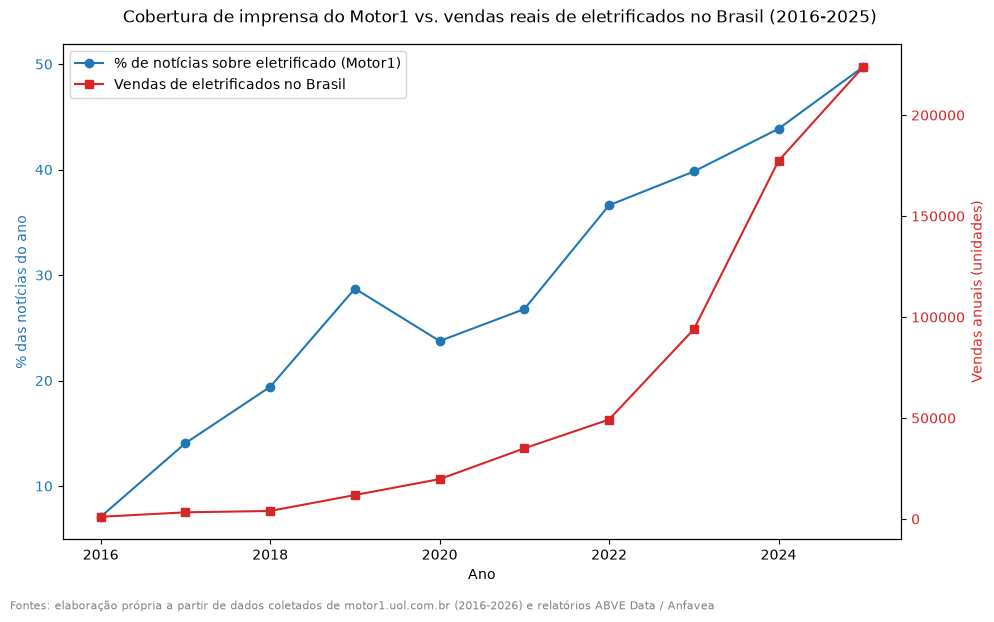

In [5]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(validacao.index, validacao["prop_eletrificado"], marker="o", color="tab:blue",
         label="% de notícias sobre eletrificado (Motor1)")
ax1.set_xlabel("Ano")
ax1.set_ylabel("% das notícias do ano", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(validacao.index, validacao["vendas_eletrificados"], marker="s", color="tab:red",
         label="Vendas de eletrificados no Brasil")
ax2.set_ylabel("Vendas anuais (unidades)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

fig.suptitle("Cobertura de imprensa do Motor1 vs. vendas reais de eletrificados no Brasil (2016-2025)")
fig.text(0.01, -0.02,
         "Fontes: elaboração própria a partir de dados coletados de motor1.uol.com.br (2016-2026) e relatórios ABVE Data / Anfavea",
         fontsize=8, color="gray")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

---
## 6. A cobertura antecipa ou acompanha? — correlação com defasagem (lag)

Olhar o gráfico já sugere que as duas curvas crescem juntas, mas isso não diz **quem vem primeiro**. Para testar isso de forma simples e estatística (sem precisar de um teste sofisticado), comparamos a correlação de Pearson entre a proporção de cobertura e as vendas em três cenários:

- **lag = -1**: cobertura do ano *anterior* vs. vendas do ano atual → se a correlação for mais forte aqui, a cobertura **antecipou** as vendas (imprensa falou primeiro, mercado vendeu depois).
- **lag = 0**: cobertura e vendas do mesmo ano → movem juntas, sem defasagem clara.
- **lag = +1**: cobertura do ano atual vs. vendas do ano *anterior* → se for mais forte aqui, a cobertura **está atrasada** em relação às vendas (o mercado já tinha crescido antes da imprensa aumentar a cobertura).

Quanto mais próximo de 1, mais forte a associação linear entre as duas séries naquele cenário de defasagem.

In [6]:
def correlacao_com_lag(serie_cobertura, serie_vendas, lag):
    """lag > 0: cobertura antecipa vendas (cobertura do ano N vs vendas do ano N+lag).
    lag < 0: cobertura está atrasada em relação às vendas."""
    cobertura_alinhada, vendas_alinhada = serie_cobertura.align(serie_vendas.shift(-lag), join="inner")
    dados_validos = pd.DataFrame({"cobertura": cobertura_alinhada, "vendas": vendas_alinhada}).dropna()
    return dados_validos["cobertura"].corr(dados_validos["vendas"]), len(dados_validos)

resultados_lag = []
for lag, descricao in [(1, "cobertura antecipa vendas em 1 ano"),
                        (0, "sem defasagem (mesmo ano)"),
                        (-1, "cobertura atrasada 1 ano em relação às vendas")]:
    corr, n = correlacao_com_lag(validacao["prop_eletrificado"], validacao["vendas_eletrificados"], lag)
    resultados_lag.append({"lag": lag, "cenario": descricao, "correlacao": round(corr, 3), "n_anos_comparados": n})

pd.DataFrame(resultados_lag)

,lag,cenario,correlacao,n_anos_comparados
0,1,cobertura antecipa vendas em 1 ano,0.876,9
1,0,sem defasagem (mesmo ano),0.869,10
2,-1,cobertura atrasada 1 ano em relação às vendas,0.864,9


---
## 7. Salvando os resultados

In [7]:
validacao.to_csv(ARQUIVO_SAIDA)
print(f"Tabela salva em: {ARQUIVO_SAIDA}")

Tabela salva em: C:\Users\muvil\projeto-2-de-perspectiva-em-ciencia-de-dados\projeto\dados\validacao_externa_cobertura_vendas.csv


---
## Conclusão da Etapa 6

- A proporção de notícias do Motor1 sobre veículos elétricos/híbridos e o volume real de vendas de eletrificados no Brasil crescem **juntos** ao longo de 2016–2025 — as duas curvas sobem de forma consistente, sem nenhum ano de descolamento brusco entre elas.
- A correlação de Pearson é forte nos três cenários de defasagem testados (0,876 quando a cobertura antecipa vendas em 1 ano; 0,869 sem defasagem; 0,864 quando a cobertura está atrasada em 1 ano). **As diferenças entre os três cenários são pequenas demais, com apenas 9-10 pontos anuais, para afirmar com confiança que existe uma defasagem real em qualquer direção** — o resultado honesto é que a correlação é forte em geral, mas o teste não tem poder estatístico suficiente para dizer se a cobertura antecipa, acompanha ou atrasa em relação às vendas.
- Isso ainda responde à pergunta-guia do projeto, só que de forma mais cautelosa do que uma conclusão categórica: com os dados anuais disponíveis, **não há evidência estatística suficiente de que o Motor1 antecipou a transição elétrica** — o que se observa é um acompanhamento próximo e contemporâneo do mercado, consistente com o que já vinha sendo sugerido pela Etapa 1 (crescimento significativo, mas concomitante).
- **Limitação importante:** com apenas 10 pontos anuais (2016–2025), qualquer teste de defasagem tem pouquíssimo poder estatístico — a diferença entre lag = +1, 0 e -1 pode facilmente ser ruído. Uma extensão natural, se sobrar tempo, seria repetir esta análise com dados **mensais** de vendas da ABVE em vez de anuais (mais de 100 pontos em vez de 10), o que daria poder estatístico real para um teste de defasagem ou até um teste de causalidade de Granger.